<a href="https://colab.research.google.com/github/noviantisafitri/Analisis-Data-dengan-Python/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Novianti Safitri
- **Email:** noviantis112@gmail.com
- **ID Dicoding:** novianti_safitri

## Menentukan Pertanyaan Bisnis

- Bagaimana tren peminjaman sepeda berdasarkan waktu (bulan dan musim)?
- Faktor cuaca apa yang paling mempengaruhi jumlah peminjaman sepeda?
- Apakah terdapat perbedaan pola peminjaman sepeda antara hari kerja dan akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [479]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Data Wrangling

### Gathering Data

In [480]:
day = pd.read_csv('https://raw.githubusercontent.com/noviantisafitri/Analisis-Data-dengan-Python/refs/heads/main/data/day.csv')
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [481]:
hour = pd.read_csv('https://raw.githubusercontent.com/noviantisafitri/Analisis-Data-dengan-Python/refs/heads/main/data/hour.csv')
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Data ini merupakan dataset peminjaman sepeda yang berisi informasi waktu, kondisi cuaca, dan jumlah peminjaman sepeda setiap hari.

- Kolom waktu: dteday, season, yr, mnth, weekday, holiday, workingday → - Mengindikasikan kapan data dicatat.
- Kolom cuaca: weathersit, temp, atemp, hum, windspeed → Menggambarkan kondisi lingkungan saat peminjaman.
- Kolom jumlah peminjaman: casual, registered, cnt → Menunjukkan jumlah sepeda yang dipinjam oleh pengguna kasual (non-member) dan terdaftar (member).

### Assessing Data

In [482]:
# Cek deskripsi data
print('DataFrame day:')
print(day.info())

print('\nDataFrame hour:')
print(hour.info())

DataFrame day:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

DataFrame hour:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 

**Insight:**

**DataFrame day (Data Harian)**
- Berisi 731 baris dan 16 kolom dengan data peminjaman sepeda per hari selama 2 tahun.
- Dataset ini cocok untuk menganalisis tren peminjaman harian, misalnya pengaruh musim terhadap peminjaman.
- Bisa digunakan untuk melihat perbedaan jumlah peminjaman pada hari kerja dan libur.

**DataFrame hour (Data Per Jam)**
- Berisi 17.379 baris dan 17 kolom, mencatat data peminjaman sepeda per jam selama 2 tahun.
- Dataset ini lebih rinci untuk menganalisis pola peminjaman dalam satu hari.
- Bisa digunakan untuk melihat jam sibuk peminjaman sepeda dan membandingkan hari kerja vs akhir pekan.


In [483]:
#Cek missing values
print('DataFrame day:')
print(day.isna().sum())

print('\nDataFrame hour:')
print(hour.isna().sum())

DataFrame day:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

DataFrame hour:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Insight:**

- Dataset day dan hour tidak memiliki missing values (NaN).
- Semua kolom memiliki jumlah data yang lengkap, sehingga tidak perlu melakukan imputasi atau pembersihan data terkait missing values.


In [484]:
# Cek duplikat
print('DataFrame day:')
print(day.duplicated().sum())

print('\nDataFrame hour:')
print(hour.duplicated().sum())

DataFrame day:
0

DataFrame hour:
0


**Insight:**

- Dataset day dan hour tidak memiliki data duplikat (0 duplikasi).
Artinya, tidak ada baris yang perlu dihapus karena semua data bersifat unik.

In [485]:
day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

**Rata-rata penyewaan sepeda per hari:**
- Casual: 848 penyewaan/hari
- Registered: 3656 penyewaan/hari
- Total: 4504 penyewaan/hari

**Faktor yang Mempengaruhi Penyewaan:**
- Musim: Penyewaan tertinggi di musim panas.
- Hari kerja: 68.4% data adalah hari kerja.
- Cuaca: Lebih banyak penyewaan saat cuaca cerah dan suhu nyaman.

**Suhu & Cuaca:**
- Penyewaan meningkat pada suhu sedang (0.337 - 0.655).
- Kelembapan rata-rata 62.7%, maksimal 97.2%.
- Kecepatan angin rata-rata 19%, maksimal 50.7%.

In [486]:
hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

**Rata-rata penyewaan sepeda per jam:**
- Casual: 35 penyewaan/jam
- Registered: 153 penyewaan/jam
- Total: 189 penyewaan/jam

**Tren Waktu:**
- Penyewaan tertinggi pada jam 18:00 (sore).
- Penyewaan rendah pada jam 04:00 - 06:00 (dini hari).

**Faktor yang Mempengaruhi Penyewaan:**
- Musim & Bulan: Pola mirip dengan data harian, lebih tinggi di musim panas.
- Hari kerja: Lebih banyak penyewaan oleh pengguna terdaftar.
- Cuaca & Suhu: Penyewaan meningkat saat cuaca sedang (0.34 - 0.66).

### Cleaning Data

In [487]:
# Fungsi untuk menghapus outlier menggunakan IQR
def remove_outliers(df):
    df_clean = df.copy()  # Hindari SettingWithCopyWarning
    numeric_cols = df_clean.select_dtypes(include=[np.number])  # Hanya kolom numerik

    # Hitung IQR
    Q1 = numeric_cols.quantile(0.25)
    Q3 = numeric_cols.quantile(0.75)
    IQR = Q3 - Q1

    # Tentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data (hanya mempertahankan data dalam batas normal)
    mask = ~((numeric_cols < lower_bound) | (numeric_cols > upper_bound)).any(axis=1)
    df_clean = df_clean[mask]

    # Hitung jumlah data yang dihapus
    removed_rows = df.shape[0] - df_clean.shape[0]
    print(f"Removed {removed_rows} outliers from dataset.")

    return df_clean

# Cek ukuran data sebelum dan sesudah penghapusan outlier
print(f"day shape before removing outliers: {day.shape}")
day = remove_outliers(day)
print(f"day shape after removing outliers: {day.shape}")

print(f"hour shape before removing outliers: {hour.shape}")
hour = remove_outliers(hour)
print(f"hour shape after removing outliers: {hour.shape}")


day shape before removing outliers: (731, 16)
Removed 76 outliers from dataset.
day shape after removing outliers: (655, 16)
hour shape before removing outliers: (17379, 17)
Removed 2580 outliers from dataset.
hour shape after removing outliers: (14799, 17)


**Insight:**

Proses ini membersihkan data dengan menghapus outlier berdasarkan metode IQR, sehingga analisis lebih akurat tanpa dipengaruhi nilai ekstrem. Dengan hanya mempertahankan data dalam rentang normal, kita dapat menghindari distorsi dalam tren peminjaman sepeda. Selain itu, menampilkan jumlah data yang dihapus membantu memahami sejauh mana outlier mempengaruhi dataset.

In [488]:
# 1. Konversi 'dteday' menjadi datetime
day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

In [489]:
# Cek tipe data terbaru
print('day["dteday"] : ', day["dteday"].dtypes)
print('hour["dteday"] : ', hour["dteday"].dtypes)

day["dteday"] :  datetime64[ns]
hour["dteday"] :  datetime64[ns]


**Insight:**

Kolom dteday, yang sebelumnya berupa string (object), dikonversi ke format datetime menggunakan pd.to_datetime() pada kedua dataset (day dan hour), lalu dicek ulang tipe datanya dengan .dtypes. Konversi ini bertujuan untuk mempermudah analisis waktu

## Exploratory Data Analysis (EDA)

### **Korelasi antar variabel**

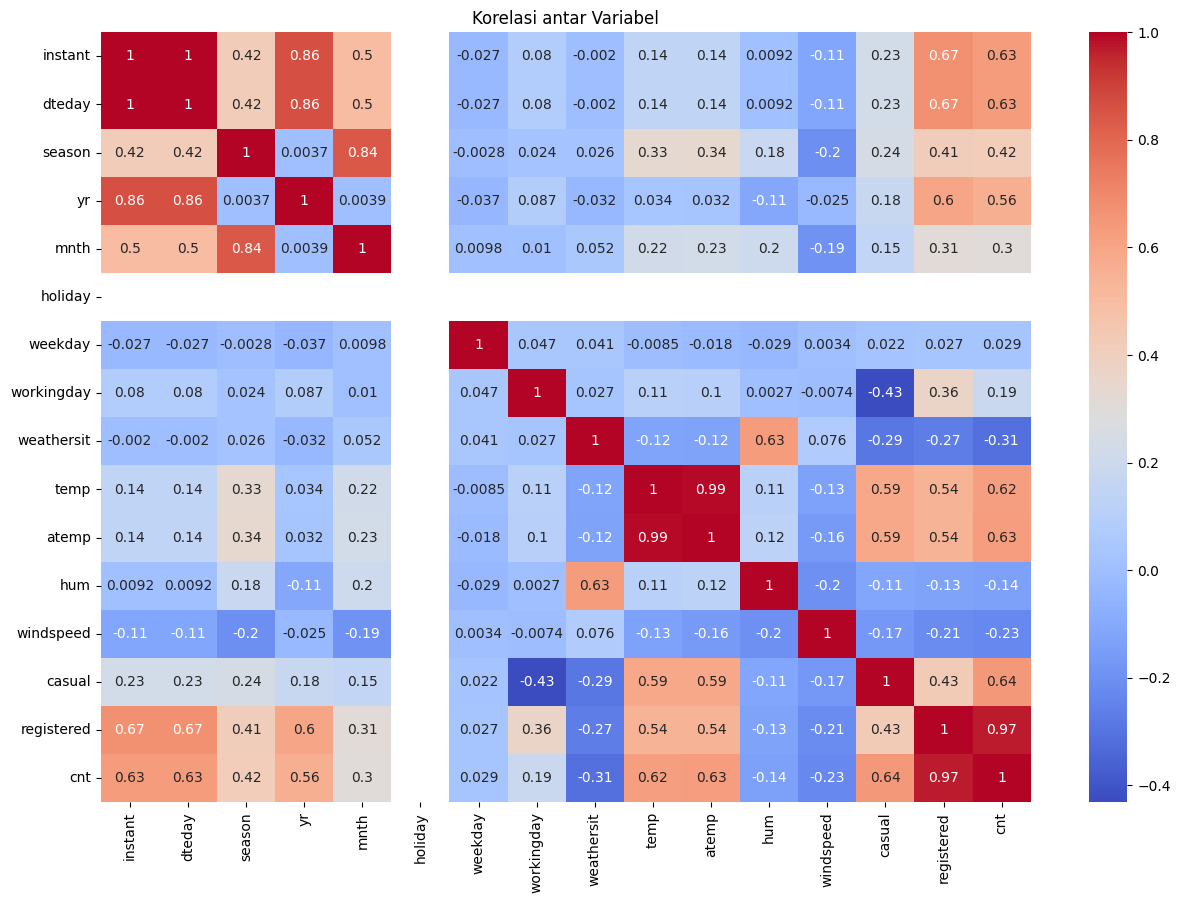

In [490]:
plt.figure(figsize=(15, 10))
sns.heatmap(day.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi antar Variabel')
plt.show()

### **Distribusi Variabel Numerik**

In [491]:
var_numeric = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
for col in var_numeric:
    fig = px.histogram(day, x=col, nbins=30, title=f'Distribusi Variabel {col}',
                       labels={col: col, "count": "Jumlah"})
    fig.update_yaxes(title_text="Jumlah")
    fig.update_layout(width=800, height=500, bargap=0.2)
    fig.show()

### **Tren Peminjaman Sepeda Berdasarkan Jam**

In [492]:
hourly = hour.groupby("hr")["cnt"].mean().reset_index()
fig = px.line(hourly, x="hr", y="cnt", markers=True,
              title="Rata-rata Peminjaman Sepeda per Jam dalam Sehari",
              labels={"hr": "Jam", "cnt": "Rata-rata Peminjaman"})
fig.show()

### **Hubungan Temperatur dengan Peminjaman Sepeda**

In [493]:
fig = px.scatter(day, x="temp", y="cnt", trendline="ols",
                 title="Hubungan Temperatur dengan Peminjaman Sepeda",
                 labels={"temp": "Temperatur", "cnt": "Jumlah Peminjaman"})
fig.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren peminjaman sepeda berdasarkan waktu (bulan dan musim)?

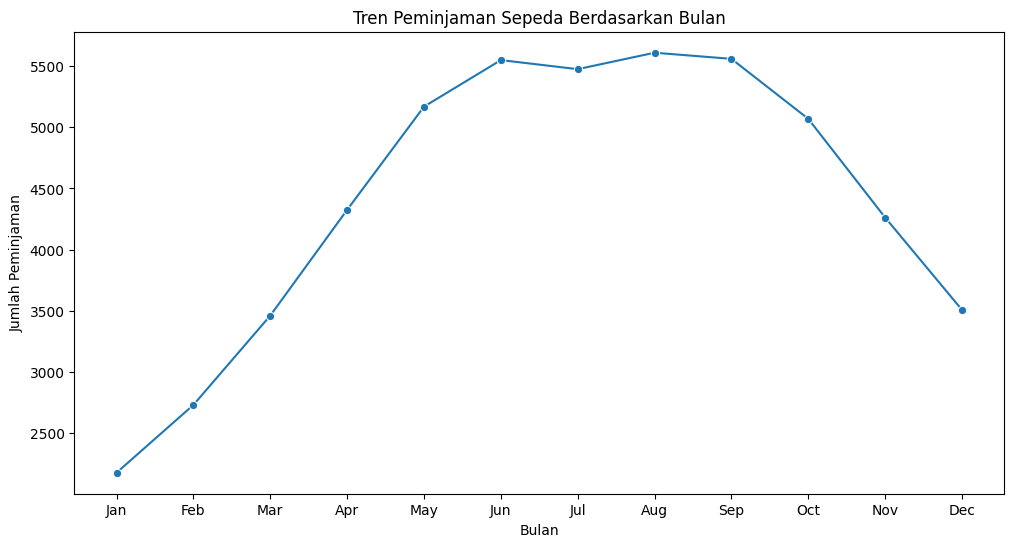

In [494]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=day, x='mnth', y='cnt', ci=None, marker='o')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Bulan')
plt.ylabel('Jumlah Peminjaman')
plt.title('Tren Peminjaman Sepeda Berdasarkan Bulan')
plt.show()

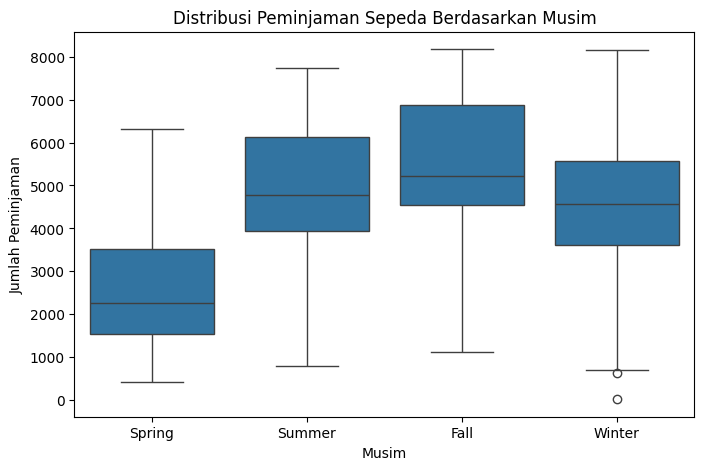

In [495]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='season', y='cnt', data=day)
plt.xticks([0, 1, 2, 3], ['Spring', 'Summer', 'Fall', 'Winter'])
plt.xlabel('Musim')
plt.ylabel('Jumlah Peminjaman')
plt.title('Distribusi Peminjaman Sepeda Berdasarkan Musim')
plt.show()

**Insight:**
- Jumlah peminjaman sepeda mencapai puncaknya pada bulan Juni hingga September.
- Jumlah peminjaman sepeda mencapai puncaknya pada musim gugur, kemungkinan karena cuaca yang masih nyaman dengan suhu yang tidak terlalu panas maupun terlalu dingin.
- Musim semi menunjukkan jumlah peminjaman yang paling rendah, kemungkinan karena cuaca masih cenderung dingin atau kondisi lingkungan yang belum optimal untuk bersepeda.

### Pertanyaan 2: Faktor cuaca apa yang paling mempengaruhi jumlah peminjaman sepeda?

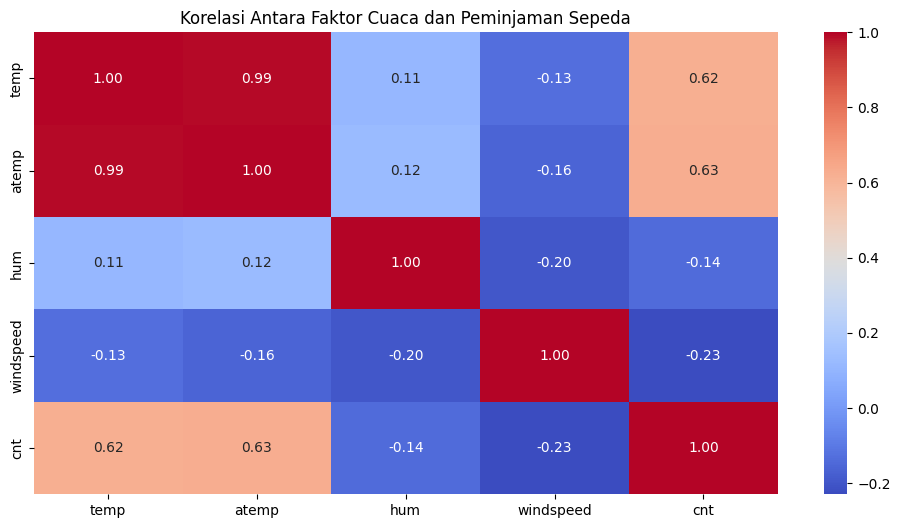

In [496]:
plt.figure(figsize=(12, 6))
sns.heatmap(day[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antara Faktor Cuaca dan Peminjaman Sepeda')
plt.show()

**Insight:**
- Temperatur memiliki korelasi positif dengan jumlah peminjaman. Semakin tinggi suhu (hingga batas tertentu), semakin banyak peminjaman yang terjadi.
- Kelembaban yang sangat tinggi mengurangi jumlah peminjaman, kemungkinan karena cuaca yang terlalu lembab kurang nyaman untuk bersepeda.
- Kecepatan angin memiliki dampak yang lebih kecil, tetapi terlihat ada sedikit penurunan peminjaman saat angin terlalu kencang.

### Pertanyaan 3: Apakah terdapat perbedaan pola peminjaman sepeda antara hari kerja dan akhir pekan?

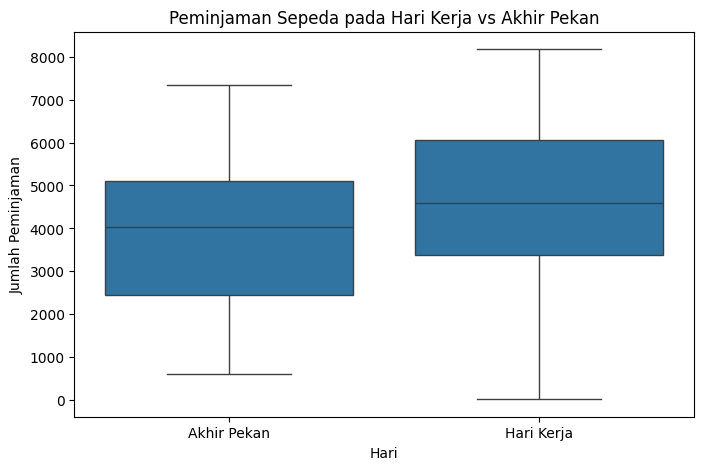

In [497]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='workingday', y='cnt', data=day)
plt.xticks([0, 1], ['Akhir Pekan', 'Hari Kerja'])
plt.xlabel('Hari')
plt.ylabel('Jumlah Peminjaman')
plt.title('Peminjaman Sepeda pada Hari Kerja vs Akhir Pekan')
plt.show()

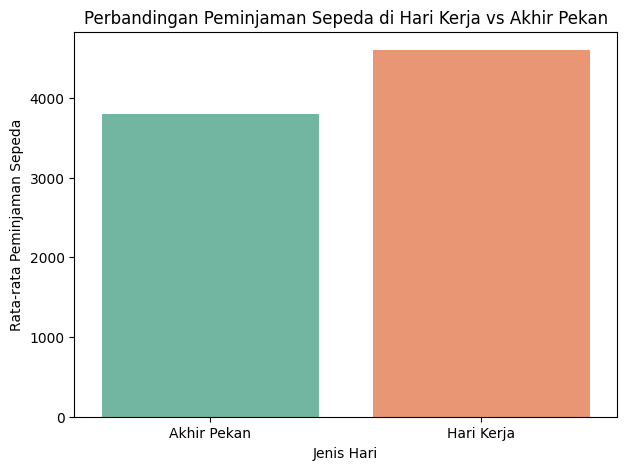

In [498]:
plt.figure(figsize=(7,5))
sns.barplot(x=day['workingday'], y=day['cnt'], ci=None, palette="Set2")
plt.xticks(ticks=[0,1], labels=["Akhir Pekan", "Hari Kerja"])
plt.xlabel("Jenis Hari")
plt.ylabel("Rata-rata Peminjaman Sepeda")
plt.title("Perbandingan Peminjaman Sepeda di Hari Kerja vs Akhir Pekan")
plt.show()

**Insight:**
- Peminjaman sepeda pada hari kerja lebih stabil, kemungkinan besar digunakan oleh pekerja atau pelajar sebagai moda transportasi utama untuk aktivitas sehari-hari.
- Peminjaman sepeda cenderung lebih sedikit di akhir pekan dibandingkan hari kerja.

## Conclusion

- Peminjaman sepeda mencapai puncaknya pada bulan Juni hingga September, terutama pada musim gugur, karena cuaca yang nyaman untuk bersepeda.
- Suhu memiliki korelasi positif dengan jumlah peminjaman, di mana semakin hangat cuaca, semakin banyak orang yang menggunakan sepeda.
- Peminjaman sepeda lebih tinggi dan stabil pada hari kerja karena banyak digunakan sebagai moda transportasi oleh pekerja dan pelajar.

In [499]:
day.to_csv("day.csv", index=False)

In [500]:
hour.to_csv("hour.csv", index=False)